In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("../data/raw/Crop_recommendation.csv")

# =====================================================
# BASIC INFORMATION
# =====================================================

print("="*50)
print("SHAPE")
print("="*50)
print(df.shape)

print("\n")

print("="*50)
print("DATA TYPES")
print("="*50)
print(df.dtypes)

print("\n")

print("="*50)
print("MISSING VALUES")
print("="*50)
print(df.isnull().sum())

print("\n")

print("="*50)
print("DUPLICATES")
print("="*50)
print(df.duplicated().sum())

print("\n")

print("="*50)
print("DESCRIPTIVE STATISTICS")
print("="*50)
print(df.describe())

print("\n")

print("="*50)
print("UNIQUE CROPS")
print("="*50)
print(df["crop_label"].nunique())

print(df["crop_label"].unique())

SHAPE
(5000, 9)


DATA TYPES
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
soil               str
crop_label         str
dtype: object


MISSING VALUES
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
soil           0
crop_label     0
dtype: int64


DUPLICATES
4000


DESCRIPTIVE STATISTICS
                 N            P            K  temperature     humidity  \
count  5000.000000  5000.000000  5000.000000  5000.000000  5000.000000   
mean     51.226400    40.841600    36.242000    23.772518    68.377278   
std      34.969383    22.755133    21.174662     4.563245    28.676976   
min       0.000000     5.000000     5.000000    10.010000    14.260000   
25%      22.000000    20.000000    19.000000    19.867500    59.250000   
50%      39.000000    41.000000    36.000000    24.365000    83.120000   
75%   

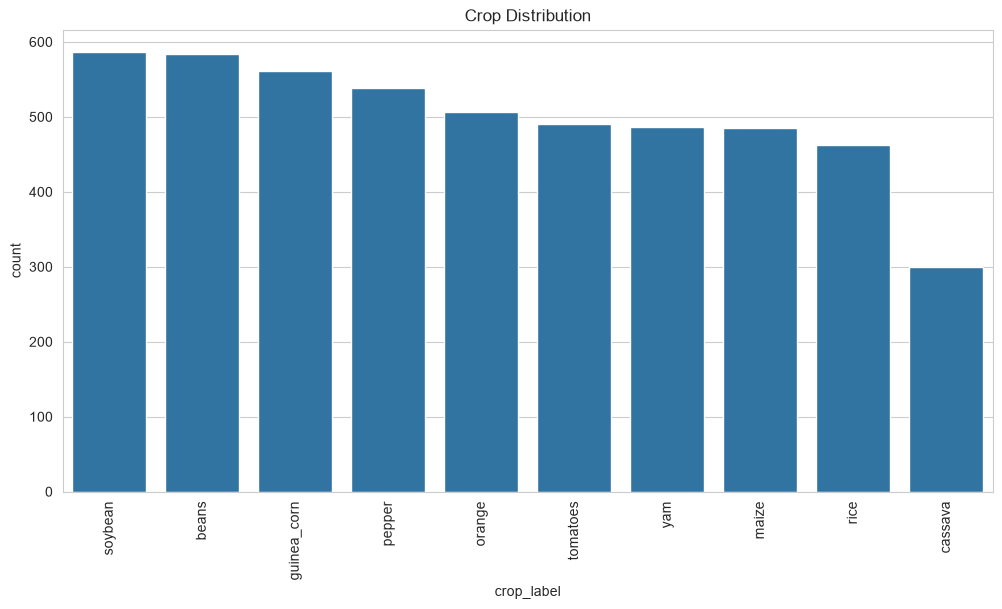

crop_label
soybean        587
beans          584
guinea_corn    561
pepper         538
orange         507
tomatoes       491
yam            486
maize          485
rice           462
cassava        299
Name: count, dtype: int64


In [6]:
#distribusi tanaman 
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="crop_label",
    order=df["crop_label"].value_counts().index
)

plt.xticks(rotation=90)
plt.title("Crop Distribution")
plt.show()

print(df["crop_label"].value_counts())

In [7]:
print(f"Jumlah Baris : {df.shape[0]}")
print(f"Jumlah Kolom : {df.shape[1]}")

Jumlah Baris : 5000
Jumlah Kolom : 9


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            5000 non-null   int64  
 1   P            5000 non-null   int64  
 2   K            5000 non-null   int64  
 3   temperature  5000 non-null   float64
 4   humidity     5000 non-null   float64
 5   ph           5000 non-null   float64
 6   rainfall     5000 non-null   float64
 7   soil         5000 non-null   str    
 8   crop_label   5000 non-null   str    
dtypes: float64(4), int64(3), str(2)
memory usage: 417.7 KB


In [9]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,51.226400,40.841600,36.242000,23.772518,68.377278,6.559738,91.334658
std,34.969383,22.755133,21.174662,4.563245,28.676976,0.650217,55.271848
min,0.000000,5.000000,5.000000,10.010000,14.260000,5.010000,20.210000
25%,22.000000,20.000000,19.000000,19.867500,59.250000,6.100000,56.020000
50%,39.000000,41.000000,36.000000,24.365000,83.120000,6.500000,80.110000
75%,84.000000,60.000000,49.000000,27.445000,90.020000,6.950000,108.480000
max,120.000000,80.000000,85.000000,34.950000,95.000000,8.870000,298.560000


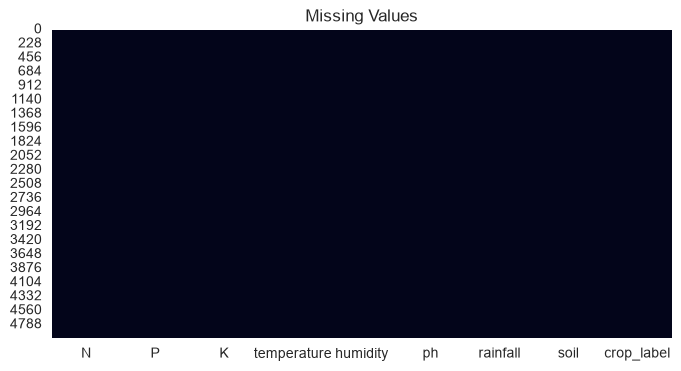

In [10]:
#missing value 
df.isnull().sum()

plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show() 

In [11]:
#duplikasi
df.duplicated().sum()

np.int64(4000)

In [12]:
#hapus duplikat
df = df.drop_duplicates()
df.shape

(1000, 9)

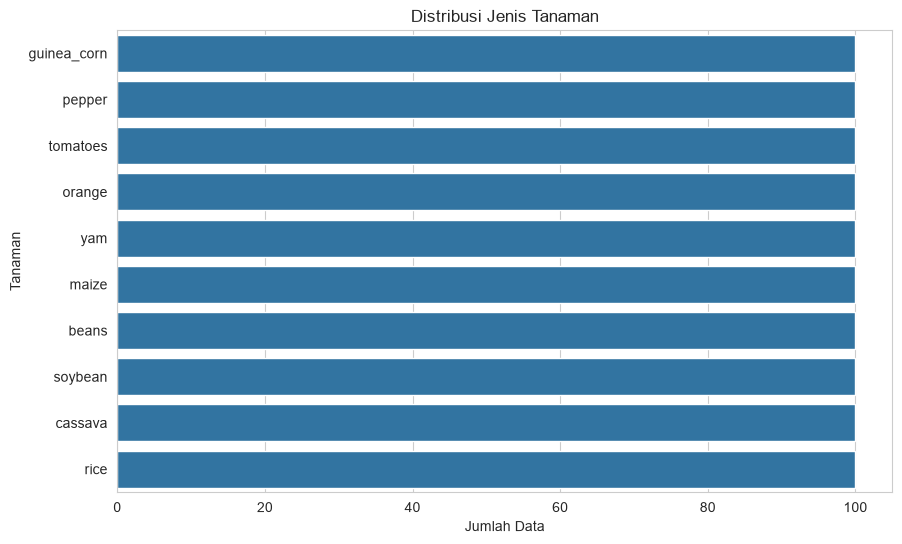

In [13]:
#distribusi target tanaman
plt.figure(figsize=(10,6))

sns.countplot(
    y='crop_label',
    data=df,
    order=df['crop_label'].value_counts().index
)

plt.title("Distribusi Jenis Tanaman")
plt.xlabel("Jumlah Data")
plt.ylabel("Tanaman")

plt.show()

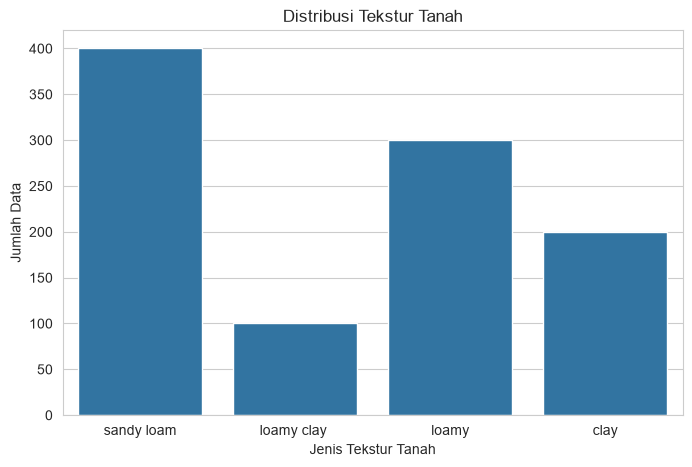

In [14]:
#analisis tekstur tanah 
plt.figure(figsize=(8,5))

sns.countplot(
    x='soil',
    data=df
)

plt.title("Distribusi Tekstur Tanah")
plt.xlabel("Jenis Tekstur Tanah")
plt.ylabel("Jumlah Data")

plt.show()

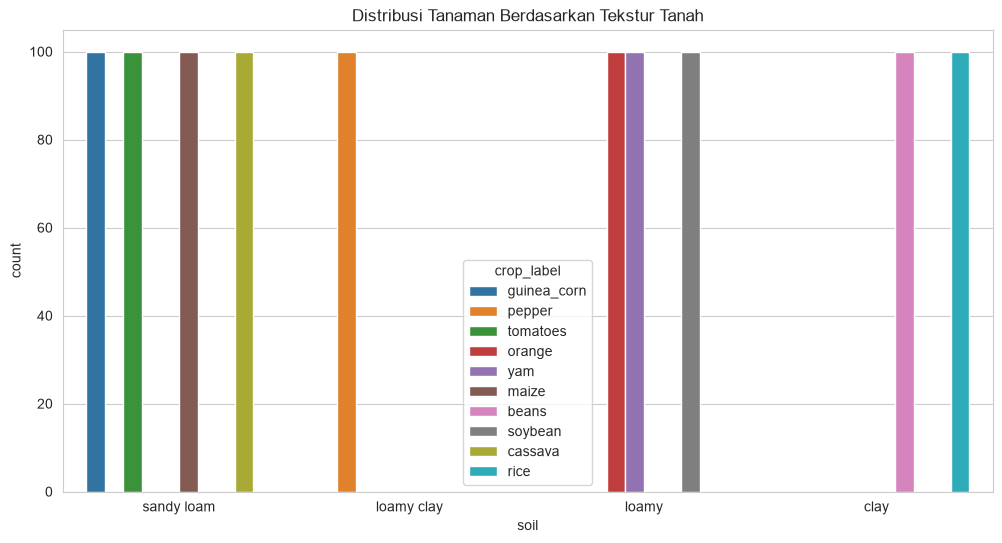

In [15]:
#tanah vs tanaman 
plt.figure(figsize=(12,6))

sns.countplot(
    x='soil',
    hue='crop_label',
    data=df
)

plt.title("Distribusi Tanaman Berdasarkan Tekstur Tanah")

plt.show()

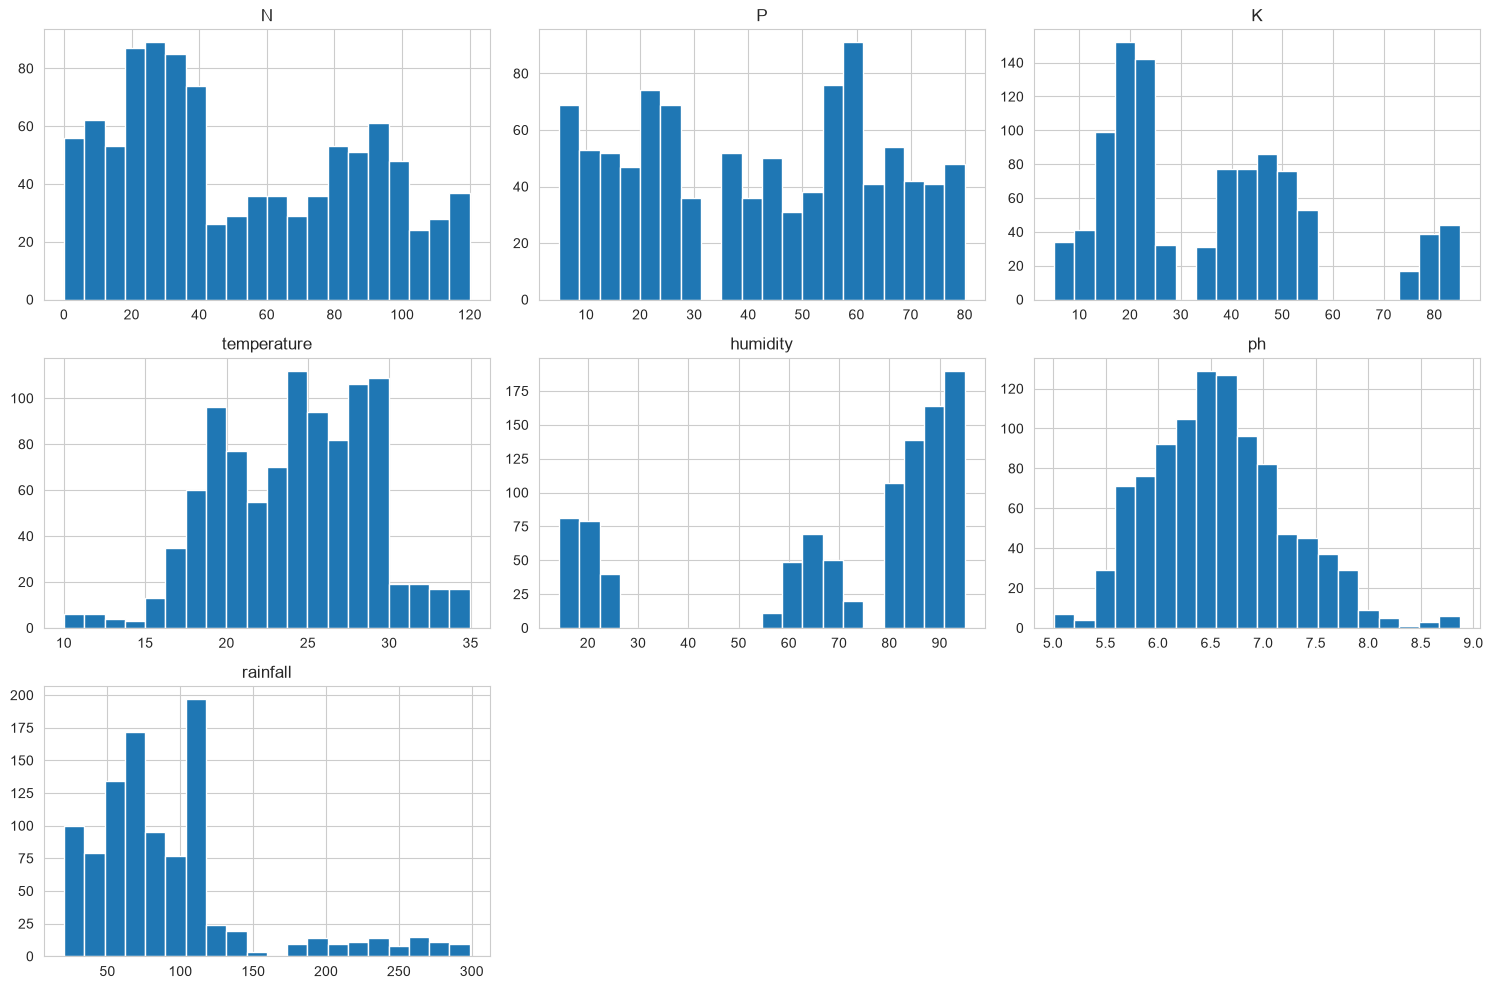

In [16]:
#histogram variabel numerik 
numerical_cols = [
    'N',
    'P',
    'K',
    'temperature',
    'humidity',
    'ph',
    'rainfall'
]

df[numerical_cols].hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.show()

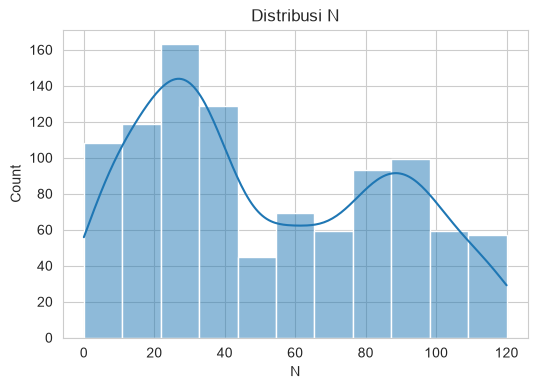

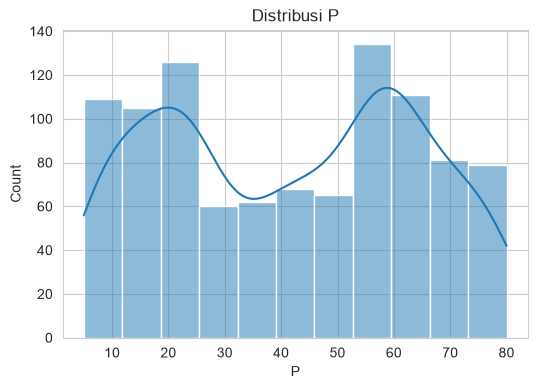

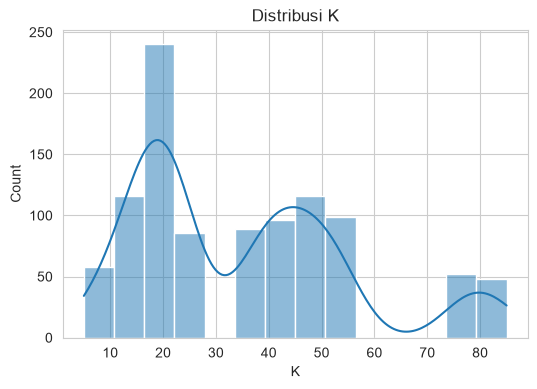

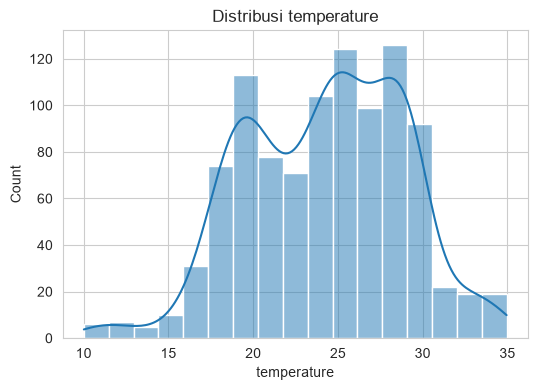

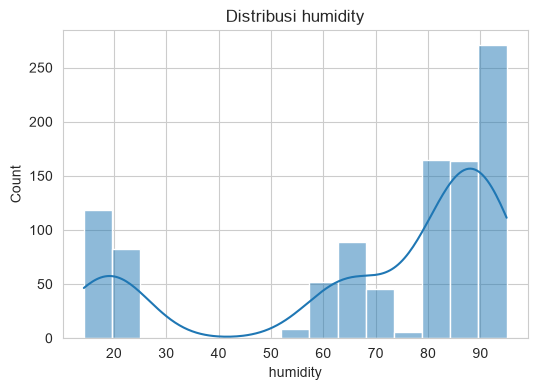

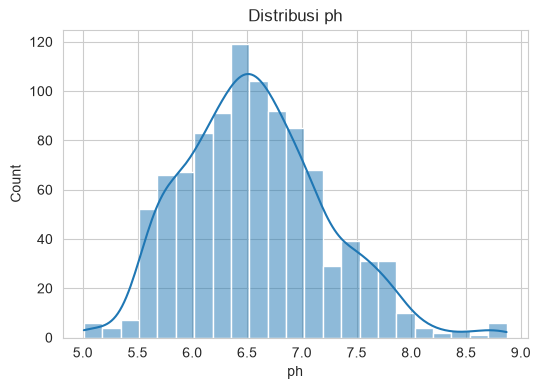

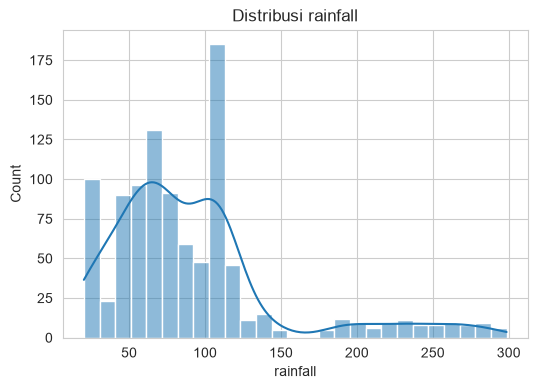

In [17]:
#distribusi per variabel 
for col in numerical_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(f"Distribusi {col}")

    plt.show()

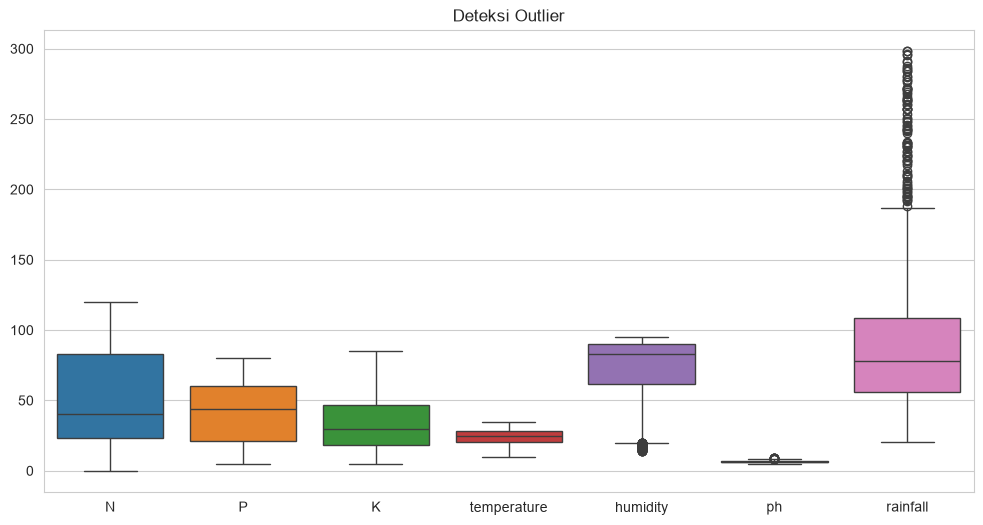

In [18]:
#boxplot outlier 
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df[numerical_cols]
)

plt.title("Deteksi Outlier")

plt.show()

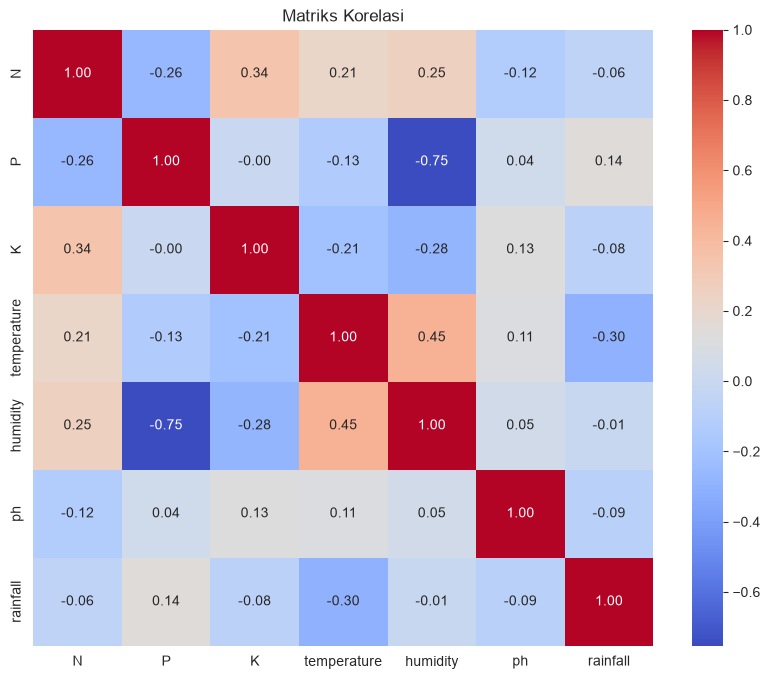

In [19]:
#correlation variable
corr = df[numerical_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Matriks Korelasi")

plt.show()

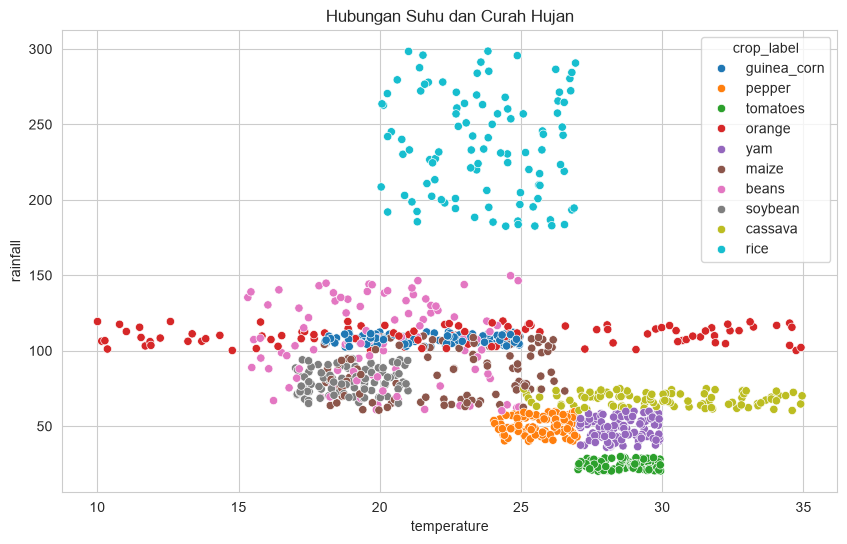

In [20]:
#temperatur vs curah hujan
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='temperature',
    y='rainfall',
    hue='crop_label'
)

plt.title("Hubungan Suhu dan Curah Hujan")

plt.show()

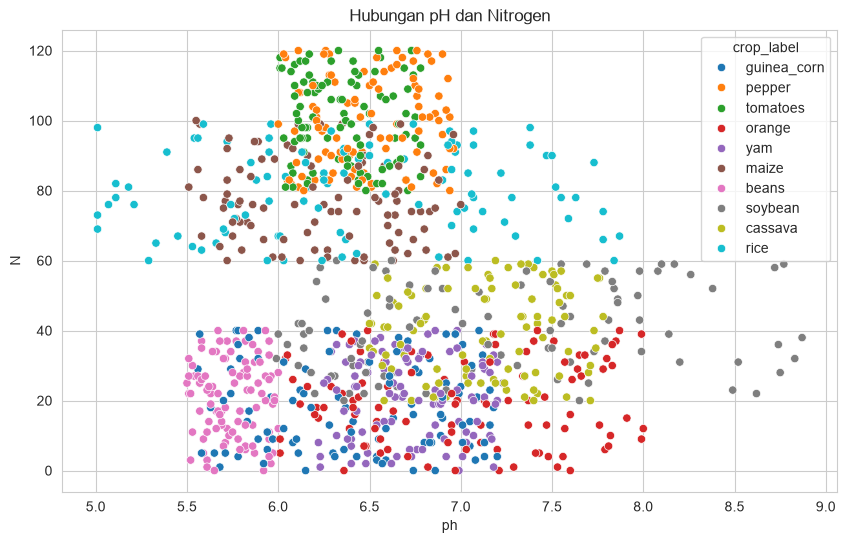

In [21]:
#ph vs N
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='ph',
    y='N',
    hue='crop_label'
)

plt.title("Hubungan pH dan Nitrogen")

plt.show()

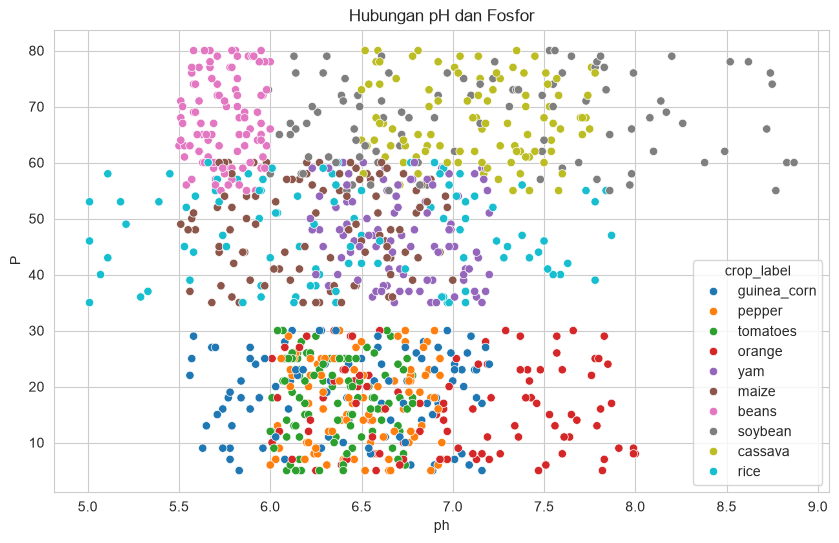

In [22]:
#ph vs P
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='ph',
    y='P',
    hue='crop_label'
)

plt.title("Hubungan pH dan Fosfor")

plt.show()

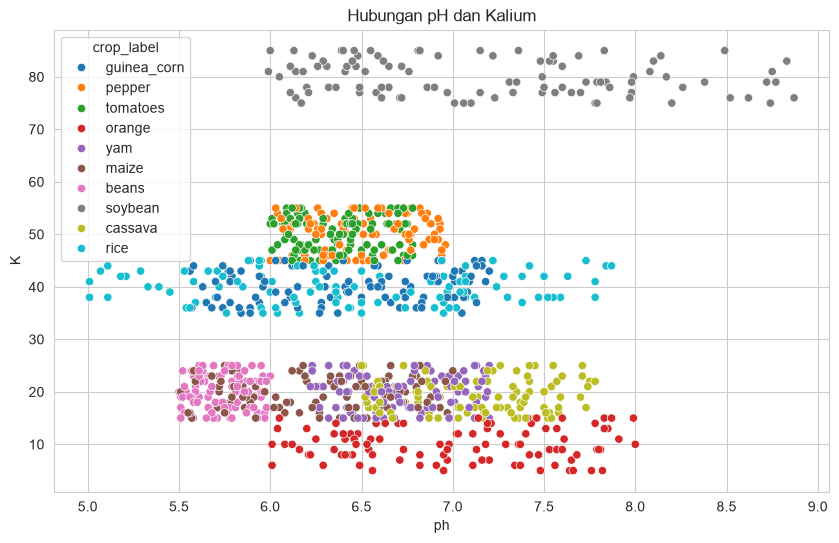

In [23]:
#ph vs K
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='ph',
    y='K',
    hue='crop_label'
)

plt.title("Hubungan pH dan Kalium")

plt.show()

In [24]:
#analisis karakteristik tanaman 
crop_summary = df.groupby("crop_label")[numerical_cols].mean()

crop_summary

,N,P,K,temperature,humidity,ph,rainfall
crop_label,,,,,,,
beans,20.75,67.54,20.05,20.1151,21.6057,5.7496,105.9194
cassava,40.02,67.47,19.24,29.9735,65.1186,7.1335,67.8845
guinea_corn,18.87,18.75,40.21,21.8376,90.1261,6.4292,107.5286
maize,77.76,48.44,19.79,22.3892,65.0920,6.2451,84.7668
orange,19.58,16.55,10.01,22.7655,92.1700,7.0173,110.4750
pepper,99.42,17.00,50.22,25.5915,85.1604,6.4957,50.7865
rice,79.89,47.58,39.87,23.6897,82.2727,6.4251,236.1810
soybean,40.09,67.79,79.92,18.8728,16.8605,7.1874,80.0596
tomatoes,100.32,17.72,50.08,28.6629,92.3432,6.3592,24.6904


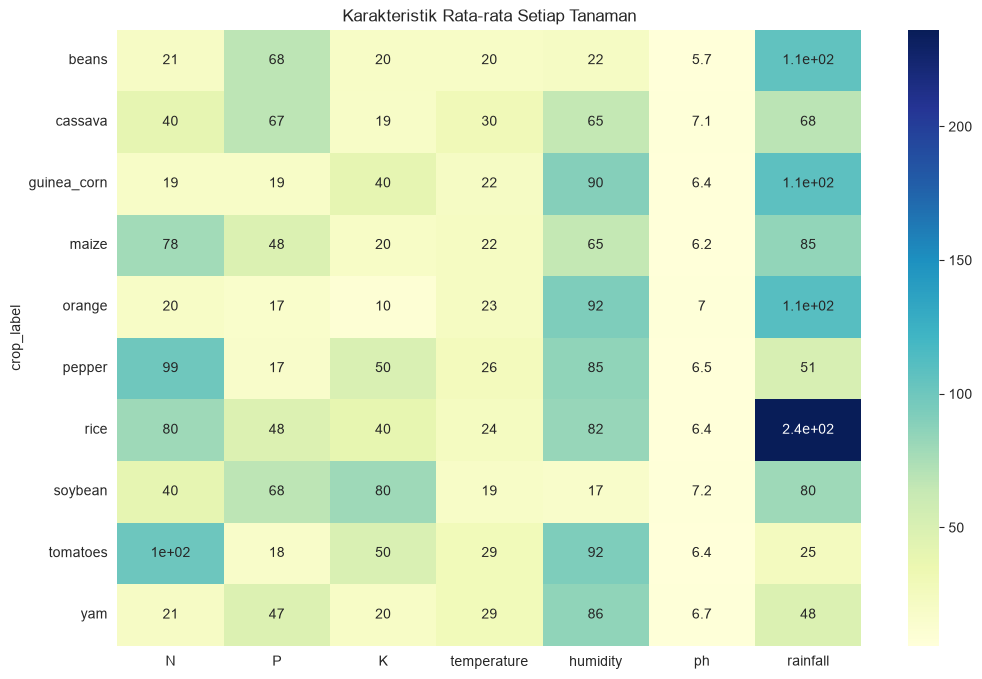

In [25]:
#heatmap tanaman 
plt.figure(figsize=(12,8))

sns.heatmap(
    crop_summary,
    annot=True,
    cmap="YlGnBu"
)

plt.title("Karakteristik Rata-rata Setiap Tanaman")

plt.show()

In [26]:
df["soil"].value_counts()

soil
sandy loam     400
loamy          300
clay           200
loamy clay     100
Name: count, dtype: int64

In [27]:
df["crop_label"].value_counts()

crop_label
guinea_corn    100
pepper         100
tomatoes       100
orange         100
yam            100
maize          100
beans          100
soybean        100
cassava        100
rice           100
Name: count, dtype: int64

In [28]:
df.describe

<bound method NDFrame.describe of         N   P   K  temperature  humidity    ph  rainfall         soil  \
0      40  27  45        21.66     94.79  5.89    112.43   sandy loam   
1     120   7  47        24.25     83.04  6.65     54.77  loamy clay    
2     102  11  47        27.99     92.78  6.50     27.15   sandy loam   
3       5  25   6        30.72     94.01  6.01    106.81        loamy   
4      36  43  21        28.36     84.86  7.14     52.93        loamy   
...   ...  ..  ..          ...       ...   ...       ...          ...   
4116  110  22  47        29.03     91.82  6.24     24.94   sandy loam   
4155   34  66  19        32.97     60.18  7.59     73.45   sandy loam   
4215   28  65  23        28.39     61.89  7.41     74.24   sandy loam   
4227  100  48  16        25.72     67.22  5.55     74.51   sandy loam   
4335   35  48  15        27.11     87.45  6.98     55.04        loamy   

       crop_label  
0     guinea_corn  
1          pepper  
2        tomatoes  
3        

In [ ]:
#Dataset acuan
1. Dataset terdiri dari 10 jenis tanaman yang umum dibudidayakan di wilayah tropis.
2. Ditemukan 4000 data duplikat yang kemudian dihapus sehingga hanya menyisakan observasi unik.
3. Tidak ditemukan missing value pada dataset.
4. Variabel N, P, K, temperature, humidity, pH, dan rainfall menunjukkan variasi yang cukup besar antar tanaman.
5. Soil texture menjadi fitur tambahan yang berpotensi meningkatkan performa model rekomendasi tanaman.
6. Setiap tanaman memiliki kombinasi kebutuhan lingkungan dan unsur hara yang berbeda sehingga memungkinkan model machine learning mempelajari pola rekomendasi secara efektif.